<a id="top"></a>
# Accessing Cloud-Hosted Data with Astroquery
***
## Learning Goals

By the end of this tutorial, you will:

-   Identify which MAST datasets are available in the cloud.
-   Use `astroquery.mast.Observations` to search for observations and associated data products.
-   Access and read data directly from the cloud without downloading files locally.
-   Apply these techniques to multiple mission data products, including images, spectra, and time-series data.

## Table of Contents

* [Introduction](#introduction)
* [Imports](#imports)
* [Identifying Cloud-Hosted Datasets](#identifying-cloud-hosted-datasets)
* [Searching for MAST Observations and Data Products](#searching-for-mast-observations-and-data-products)
* [Accessing Cloud-Hosted Data](#accessing-cloud-hosted-data)
  * [Opening a Cloud FITS File with Astropy](#opening-a-cloud-fits-file-with-astropy)
  * [Opening a Cloud File with s3fs](#opening-a-cloud-file-with-s3fs)
* [Another Example: Accessing Time-Series Data from TESS](#another-example-accessing-time-series-data-from-tess)
  * [Opening Timeseries Files with Lightkurve](#opening-timeseries-files-with-lightkurve)
* [Exercise: Accessing JWST Spectroscopic Data](#exercise-accessing-jwst-spectroscopic-data)
* [Exercise Solution](#exercise-solution)
* [Additional Resources](#additional-resources)

## Introduction

Astronomical datasets have grown dramatically in size and complexity over the past few decades. Many modern missions produce data volumes that are impractical to download and store locally. To support large-scale analysis workflows, the [Mikulski Archive for Space Telescopes (MAST)](https://archive.stsci.edu/) hosts many public datasets in the cloud.

In this context, *the cloud* refers to remote storage systems that make data available over the internet through object storage services. One widely used service is [Amazon Web Services (AWS)](https://aws.amazon.com/) [Simple Storage Service (S3)](https://aws.amazon.com/s3/), where several public MAST datasets are stored in an [Open Data Bucket](https://registry.opendata.aws/collab/stsci/). Instead of retrieving files through traditional download methods, users can access data directly from cloud storage using specialized tools and libraries.

Accessing datasets via cloud storage can provide significant advantages, allowing you to:

- Avoid transferring entire files when only a subset of the data is needed.
- Improve data access speed when working in environments with fast connections to cloud storage.
- Reduce local storage requirements by accessing files on demand.
- Simplify workflows that involve large datasets or require access to multiple files.

The [`astroquery.mast.Observations`](https://astroquery.readthedocs.io/en/latest/mast/mast_obsquery.html) interface supports both traditional downloads and direct access to cloud-hosted data products. In addition to returning metadata about observations and data products, it provides S3 Uniform Resource Identifiers (URIs) that point to the location of cloud-hosted files. 

In this notebook, we demonstrate how to:
- Identify which MAST datasets are available in cloud storage.
- Retrieve S3 URIs for cloud-hosted data products.
- Access files directly from the cloud without downloading them locally.
- Read subsets of large files using cloud access methods.

These tools allow users to incorporate cloud-hosted MAST data into their analysis workflows while minimizing data transfer and local storage requirements.

## Imports

This notebook uses the following packages:

- *matplotlib* to visualize data
- *s3fs* to access files stored in public cloud storage (e.g., AWS S3) without authentication
- *astropy* to handle FITS files and perform normalization for visualization
- *astroquery.mast* to query the MAST archive and locate data products

In [1]:
import matplotlib.pyplot as plt
import s3fs
import lightkurve as lk
from astropy.io import fits
from astropy.visualization import simple_norm
from astroquery.mast import Observations

/home/runner/micromamba/envs/ci-env/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


***

## Identifying Cloud-Hosted Datasets

Public datasets from several missions and collections are currently hosted in the cloud. To return a list of available datasets, we can use the `Observations.list_cloud_datasets()` method.

In [2]:
# List the available cloud datasets
Observations.list_cloud_datasets()

INFO: Using the S3 STScI public dataset [astroquery.mast.cloud]


['gaia',
 'galex',
 'hst',
 'jwst',
 'k2',
 'kepler',
 'mast/hlsp/jades',
 'mast/hlsp/maestro',
 'mast/hlsp/qlp',
 'mast/hlsp/s0052',
 'mast/hlsp/tess-spoc',
 'mast/hlsp/tglc',
 'panstarrs',
 'roman',
 'sdss',
 'tess']

Wow, there's a good amount of data available in the cloud! Notice that these datasets include both mission names (e.g., "hst", "kepler") and [High-Level Science Product (HLSP)](https://mast.stsci.edu/hlsp/#/) collections (e.g., “mast/hlsp/jades”).

Now that we know what data is available, we can use the `Observations` interface to search for observations and data products from these datasets.

## Searching for MAST Observations and Data Products

The `Observations` interface provides several methods to search for observational metadata archived at MAST. Queries may be based on sky coordinates, an object name, or other metadata criteria. For the purposes of this tutorial, we won't go into too much detail on how to write queries. Instead, we will focus more on how to access cloud data products once you have identified them. For a more detailed introduction to writing queries with `astroquery.mast.Observations`, please see our beginner notebook on [Searching MAST using astroquery.mast](https://spacetelescope.github.io/mast_notebooks/notebooks/multi_mission/beginner_search/beginner_search.html).

For our first example, let's search for image observations of NGC 6543 taken by the [Hubble Space Telescope (HST)](https://www.stsci.edu/hst). NGC 6543, also known as the [Cat's Eye Nebula](https://science.nasa.gov/asset/hubble/cats-eye-nebula/), is a well-known planetary nebula in the northern constellation of Draco. We'll use the `Observations.query_criteria()` method with the following parameters:

- `target_name="NGC6543"` to search for observations of the Cat's Eye Nebula.
- `obs_collection="HST"` to restrict our search to the Hubble Space Telescope.
- `dataproduct_type="image"` to look for image data products.
- `calib_level=3` to focus on fully calibrated data products that are ready for scientific analysis.
- `provenance_name='CALACS'` to select data products that were processed by the [Advanced Camera for Surveys (ACS) calibration pipeline](https://www.stsci.edu/hst/instrumentation/acs/software-tools/calibration-tools#section-7d70c566-954d-4d4c-a5cd-fd3855057b0e).

The method will return an `astropy.table.Table` containing metadata for all observations that match our criteria. We can check how many observations were returned and take a look at the first few rows of the table.

In [3]:
# Query for HST image observations of NGC6543
hst_obs = Observations.query_criteria(target_name="NGC6543",
                                      obs_collection="HST",
                                      dataproduct_type="image",
                                      calib_level=3,
                                      provenance_name="CALACS")

print(f"Number of observations: {len(hst_obs)}")
hst_obs[:5]

Number of observations: 12


intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max
str7,str3,str6,str7,str3,str6,str7,str7,str46,str9,float64,float64,str5,str20,int64,float64,float64,float64,str7,float64,float64,str20,float64,str4,str7,int64,str479,str34,str35,str6,bool,float64,str8,str10,float64,float64
science,HST,CALACS,ACS/HRC,HST,FR656N,OPTICAL,NGC6543,ISM;PLANETARY NEBULA;;ISM;EMISSION LINE NEBULA,j8cka1040,269.6387083333,66.63302777778,image,"Tsvetanov, Zlatan I.",3,52398.87011211806,52398.87875787037,700.0,OPTICAL,627.4,684.8,ACS Ramp Filter Test,52394.7083333,9026,SM3/ACS,--,POLYGON -90.35868499999998 66.62750253 -90.34847491 66.63328485 -90.36390461000002 66.6385638 -90.37411326 66.63278047 -90.35868499999998 66.62750253 -90.35868499999998 66.62750253,mast:HST/product/j8cka1041_drz.jpg,mast:HST/product/j8cka1041_drz.fits,PUBLIC,False,nan,26095321,902297969,627.4,684.8
science,HST,CALACS,ACS/HRC,HST,F658N,OPTICAL,NGC6543,ISM;PLANETARY NEBULA;;ISM;EMISSION LINE NEBULA,j8cka1050,269.6387083333,66.63302777778,image,"Tsvetanov, Zlatan I.",3,52398.91740358796,52398.926049340276,700.0,OPTICAL,654.2,662.0,ACS Ramp Filter Test,52394.7083333,9026,SM3/ACS,--,POLYGON -90.35868499999998 66.62750253 -90.34847491 66.63328485 -90.36390461000002 66.6385638 -90.37411326 66.63278047 -90.35868499999998 66.62750253 -90.35868499999998 66.62750253,mast:HST/product/j8cka1051_drz.jpg,mast:HST/product/j8cka1051_drz.fits,PUBLIC,False,nan,26098620,902298510,654.2,662.0
science,HST,CALACS,ACS/WFC,HST,FR505N,OPTICAL,NGC6543,ISM;PLANETARY NEBULA;;ISM;EMISSION LINE NEBULA,j8ck01020,269.6387083333,66.63302777778,image,"Tsvetanov, Zlatan I.",3,52398.665077314814,52398.67475304398,700.0,OPTICAL,482.40000000000003,526.5999999999999,ACS Ramp Filter Test,52394.7083333,9026,SM3/ACS,--,POLYGON -90.312547049999679 66.636953139999932 -90.273529349999677 66.661019209999893 -90.3884753199998 66.694853210000076 -90.42743439999974 66.670758699999951 -90.312547049999679 66.636953139999932 -90.312547049999679 66.636953139999932 POLYGON -90.35209913999995 66.61285399999997 -90.314906890000117 66.636242439999947 -90.427319179999643 66.670250990000071 -90.464456199999717 66.646836019999952 -90.35209913999995 66.61285399999997 -90.35209913999995 66.61285399999997,mast:HST/product/j8ck01021_drz.jpg,mast:HST/product/j8ck01021_drz.fits,PUBLIC,False,nan,26098573,902339074,482.40000000000003,526.5999999999999
science,HST,CALACS,ACS/WFC,HST,FR656N,OPTICAL,NGC6543,ISM;PLANETARY NEBULA;;ISM;EMISSION LINE NEBULA,j8ck01060,269.6387083333,66.63302777778,image,"Tsvetanov, Zlatan I.",3,52398.78400100694,52398.79367673611,700.0,OPTICAL,627.4,684.8,ACS Ramp Filter Test,52394.7083333,9026,SM3/ACS,--,POLYGON -90.312547049999679 66.636953139999932 -90.273529349999677 66.661019209999893 -90.3884753199998 66.694853210000076 -90.42743439999974 66.670758699999951 -90.312547049999679 66.636953139999932 -90.312547049999679 66.636953139999932 POLYGON -90.35209913999995 66.61285399999997 -90.314906890000117 66.636242439999947 -90.427319179999643 66.670250990000071 -90.464456199999717 66.646836019999952 -90.35209913999995 66.61285399999997 -90.35209913999995 66.61285399999997,mast:HST/product/j8ck01061_drz.jpg,mast:HST/product/j8ck01061_drz.fits,PUBLIC,False,nan,26091354,1110895514,627.4,684.8
science,HST,CALACS,ACS/HRC,HST,FR388N,OPTICAL,NGC6543,ISM;PLANETARY NEBULA;;ISM;EMISSION LINE NEBULA,j8cka1010,269.6387083333,66.63302777778,image,"Tsvetanov, Zlatan I.",3,52398.8062346875,52398.814880439815,700.0,OPTICAL,371.0,404.9,ACS Ramp Filter Test,52394.7083333,9026,SM3/ACS,--,POLYGON -90.35868499999998 66.62750253 -90.34847491 66.63328485 -90.36390461000002 66.6385638 -90.37411326 66.63278047 -90.3586849999

Great, we found some observations! Each observation archived at MAST may be associated with one or more data products, including images, spectra, time-series files, previews, or ancillary metadata. 

Next, we can use the `Observations.get_unique_product_list()` method to retrieve a list of de-duplicated data products associated with these observations. This method will return another `astropy.table.Table` that includes metadata for each data product.

In [4]:
# Get unique products for these observations
hst_prods = Observations.get_unique_product_list(hst_obs)
hst_prods[:5]

INFO: 55 of 566 products were duplicates. Only returning 511 unique product(s). [astroquery.mast.utils]
INFO: To return all products, use `Observations.get_product_list` [astroquery.mast.observations]


obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str8,str3,str5,str35,str64,str1,str94,str9,str28,str11,str1,str7,str20,str4,str49,int64,str8,str6,int64,str9
25516311,HLA,image,hst_9026_01_acs_wfc_f502n_01,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_9026_01_acs_wfc_f502n_01,PREVIEW,--,--,--,HLA,--,9026,hst_9026_01_acs_wfc_f502n_01_drz.jpg,--,26095264,PUBLIC,2,F502N
25516311,HLA,image,hst_9026_01_acs_wfc_f502n_01,HLA simple fits science image,S,mast:HLA/url/cgi-bin/getdata.cgi?dataset=hst_9026_01_acs_wfc_f502n_01_drz.fits,SCIENCE,--,DRZ,--,HLA,--,9026,hst_9026_01_acs_wfc_f502n_01_drz.fits,138614400,26095264,PUBLIC,2,F502N
25516312,HLA,image,hst_9026_01_acs_wfc_f502n_02,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_9026_01_acs_wfc_f502n_02,PREVIEW,--,--,--,HLA,--,9026,hst_9026_01_acs_wfc_f502n_02_drz.jpg,--,26095264,PUBLIC,2,F502N
25516312,HLA,image,hst_9026_01_acs_wfc_f502n_02,HLA simple fits science image,S,mast:HLA/url/cgi-bin/getdata.cgi?dataset=hst_9026_01_acs_wfc_f502n_02_drz.fits,SCIENCE,--,DRZ,--,HLA,--,9026,hst_9026_01_acs_wfc_f502n_02_drz.fits,138614400,26095264,PUBLIC,2,F502N
25516313,HLA,image,hst_9026_01_acs_wfc_f658n_01,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_9026_01_acs_wfc_f658n_01,PREVIEW,--,--,--,HLA,--,9026,hst_9026_01_acs_wfc_f658n_01_drz.jpg,--,26095265,PUBLIC,2,F658N


These observations alone returned over 500 unique products! We are not interested in all of them, and luckily, we have a handy function to filter them for us. `Observations.filter_products()` allows us to filter based on file extension, whether a product is a minimum recommended product, and any other metadata column in the products table. 

For this example, let's filter for the following:
- `mrp_only=True` to select only the minimum recommended products (MRPs) for each observation. MRPs are a subset of data products that are recommended for scientific analysis based on quality and calibration level.
- `productSubGroupDescription="DRZ"` to select calibrated image products that combine multiple exposures using the Drizzle algorithm. DRZ products are often used for scientific analysis as they have been processed to correct for geometric distortion and combine multiple exposures to improve signal-to-noise.

In [5]:
# Filter for MRP products and DRZ images
filtered_hst_prods = Observations.filter_products(hst_prods,
                                                  mrp_only=True,
                                                  productSubGroupDescription="DRZ")
filtered_hst_prods

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str8,str3,str5,str35,str64,str1,str94,str9,str28,str11,str1,str7,str20,str4,str49,int64,str8,str6,int64,str9
26091352,HST,image,j8ck01040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8ck01041_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8ck01041_drz.fits,214300800,26091352,PUBLIC,3,FR656N
26091354,HST,image,j8ck01060,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8ck01061_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8ck01061_drz.fits,214352640,26091354,PUBLIC,3,FR656N
26095264,HST,image,j8ck01030,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8ck01031_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8ck01031_drz.fits,214404480,26095264,PUBLIC,3,F502N
26095265,HST,image,j8ck01050,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8ck01051_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8ck01051_drz.fits,214352640,26095265,PUBLIC,3,F658N
26095321,HST,image,j8cka1040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8cka1041_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.10.0,9026,j8cka1041_drz.fits,15963840,26095321,PUBLIC,3,FR656N
26095326,HST,image,j8cka1030,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8cka1031_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8cka1031_drz.fits,15963840,26095326,PUBLIC,3,F502N
26098573,HST,image,j8ck01020,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8ck01021_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.10.0,9026,j8ck01021_drz.fits,214300800,26098573,PUBLIC,3,FR505N
26098577,HST,image,j8ck01010,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8ck01011_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8ck01011_drz.fits,214352640,26098577,PUBLIC,3,FR388N
26098612,HST,image,j8cka1010,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/j8cka1011_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALACS,DrizzlePac 3.11.0,9026,j8cka1011_drz.fits,15963840,26098612,PUBLIC,3,FR388N


## Accessing Cloud-Hosted Data

At this point, in a traditional workflow, we might use the `Observations.download_products()` method to download these files to our local machine. However, since these data products are hosted in the cloud, we can access them directly without downloading. 

To retrieve a list of S3 URIs for a set of products, we can use the `Observations.get_cloud_uris()` method, which accepts either:
- A table of data products (like the one we have after filtering)
- Observation query criteria (as keyword arguments) and optional product filters (through the `mrp_only`, `extension`, and `filter_products` parameters)

S3 URIs may be returned as:
- Native S3 URIs (e.g., `s3://stpubdata...`)
- HTTP URLs suitable for streaming (set `full_url=True` and `include_bucket=False`)
- A mapping between MAST URIs and S3 URIs (set `return_uri_map=True`)

If a particular product is not hosted in the cloud, the corresponding URI will be returned as `None`.

To continue with our example, let's retrieve the S3 URIs for our filtered HST products. We can simply pass our `filtered_hst_prods` table to the `Observations.get_cloud_uris()` method.

In [6]:
# Get a list cloud URIs for the filtered products
hst_s3_uris = Observations.get_cloud_uris(filtered_hst_prods)
hst_s3_uris

['s3://stpubdata/hst/public/j8ck/j8ck01040/j8ck01041_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8ck01060/j8ck01061_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8ck01030/j8ck01031_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8ck01050/j8ck01051_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8cka1040/j8cka1041_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8cka1030/j8cka1031_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8ck01020/j8ck01021_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8ck01010/j8ck01011_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8cka1010/j8cka1011_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8cka1060/j8cka1061_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8cka1020/j8cka1021_drz.fits',
 's3://stpubdata/hst/public/j8ck/j8cka1050/j8cka1051_drz.fits']

In some cases, it may be useful to have a mapping between MAST URIs and S3 URIs. MAST URIs are unique identifiers for data products in the MAST archive and are given in the `dataURI` column of the product table. S3 URIs point to the location of files in cloud storage. To retrieve this mapping, we can set `return_uri_map=True` when calling `get_cloud_uris()`.

In [7]:
# Get a list cloud URIs for the filtered products
hst_s3_uri_map = Observations.get_cloud_uris(filtered_hst_prods, return_uri_map=True)
hst_s3_uri_map

{np.str_('mast:HST/product/j8ck01041_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8ck01040/j8ck01041_drz.fits',
 np.str_('mast:HST/product/j8ck01061_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8ck01060/j8ck01061_drz.fits',
 np.str_('mast:HST/product/j8ck01031_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8ck01030/j8ck01031_drz.fits',
 np.str_('mast:HST/product/j8ck01051_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8ck01050/j8ck01051_drz.fits',
 np.str_('mast:HST/product/j8cka1041_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8cka1040/j8cka1041_drz.fits',
 np.str_('mast:HST/product/j8cka1031_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8cka1030/j8cka1031_drz.fits',
 np.str_('mast:HST/product/j8ck01021_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8ck01020/j8ck01021_drz.fits',
 np.str_('mast:HST/product/j8ck01011_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8ck01010/j8ck01011_drz.fits',
 np.str_('mast:HST/product/j8cka1011_drz.fits'): 's3://stpubdata/hst/public/j8ck/j8cka1010/j8cka1011_drz

### Opening a Cloud FITS File with Astropy

Now that we know exactly where our data is located in the cloud, we can access it directly in cloud-based workflows or with cloud-enabled libraries such as [Astropy](https://docs.astropy.org/en/stable/io/fits/usage/cloud.html). To read a FITS file directly from an S3 URI, we can use the `astropy.io.fits.open()` function with the S3 URI and the appropriate `fsspec` keyword arguments. We need to set `anon=True` in `fsspec_kwargs` to indicate that we are accessing public data without authentication.

To start, let's inspect the first file in our list of S3 URIs. We'll read in the science data and plot the image using `matplotlib`.

Filename: <class 's3fs.core.S3File'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     753   ()      
  1  SCI           1 ImageHDU        82   (4214, 4235)   float32   
  2  WHT           1 ImageHDU        44   (4214, 4235)   float32   
  3  CTX           1 ImageHDU        37   (4214, 4235)   int32   
  4  HDRTAB        1 BinTableHDU    595   4R x 293C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 10A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 7A, L, D, D, D, 23A, 1A, K, D, D, D, D, D, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 3A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 18A, 3A, K, 7A, 6A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 1A, D, 3A, 6A, K, D, D, D, D, D, D, D, D, D, D, 23A, D, D, D, D, 3A, D

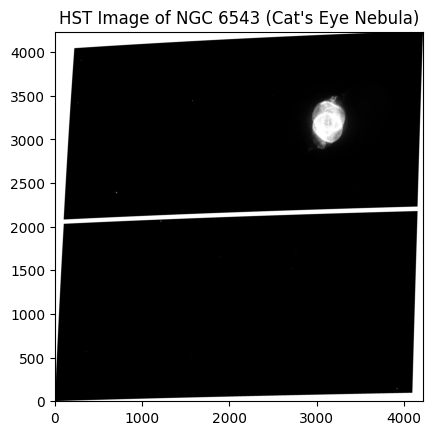

In [8]:
# this cell is SLOW; see the following cell for the fast implementation
with fits.open(hst_s3_uri_map["mast:HST/product/j8ck01041_drz.fits"],
               fsspec_kwargs={'anon': True}) as hst_hdul:  
    hst_hdul.info()
    # The science data is stored in the "SCI" extension of the FITS file. We can access it using the `data` attribute of the corresponding `ImageHDU` object.
    data = hst_hdul["SCI"].data

# Plot the image data
norm = simple_norm(data, stretch='asinh', percent=99.5)
plt.imshow(data, origin='lower', cmap='gray', norm=norm)
plt.title("HST Image of NGC 6543 (Cat's Eye Nebula)")
plt.show()

Notice that this is a relatively large image. To fully read in the data, we had to wait for the entire file to be transferred from the cloud. Depending on your internet connection and the size of the file, this may take some time.

If we only wanted to read in a subset of the data, we could use the [`section`](https://docs.astropy.org/en/stable/io/fits/usage/image.html#data-sections) attribute of the `ImageHDU` object. By indexing into the section object, we can access only the portion of the file that we need, which can significantly reduce data transfer time for large files. Keep in mind that the `section` attribute is only available for `ImageHDU` and `CompImageHDU` objects, so this method is specific to image data products.

Let's read in the same file again, but this time, we'll access the `section` attribute and zoom in on a the region of the image containing the nebula. You'll notice that this cell executes much faster since we are only reading in a small portion of the data instead of the entire file.

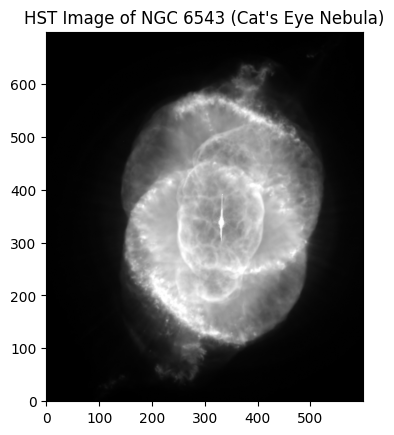

In [9]:
with fits.open(hst_s3_uris[0], use_fsspec=True, fsspec_kwargs={'anon': True}) as hst_hdul:
    # Access the `section` attribute to only read in a subset of the file
    data = hst_hdul["SCI"].section[2850:3550, 2800:3400]

# Plot the image data
norm = simple_norm(data, stretch='asinh', percent=99.5)
plt.imshow(data, origin='lower', cmap='gray', norm=norm)
plt.title("HST Image of NGC 6543 (Cat's Eye Nebula)")
plt.show()

What a beautiful nebula! By accessing the data directly from the cloud and only reading in the section of the file that we needed, we were able to visualize this image much more quickly than if we had downloaded the entire file locally.

### Opening a Cloud File with s3fs

You may wish to open a cloud file that is not in FITS format, and in this case, the [`s3fs`](https://s3fs.readthedocs.io/en/latest/#) package will come in handy. `s3fs` is a Pythonic file interface to Amazon S3 that allows you to browse and access cloud files as if they were local. 

You can access data from cloud files using the `s3fs.S3FileSystem.open` function and perform further operations within the function's context. Below, we open a FITS file with `s3fs` and open it again with `astropy.io.fits` to access its content. If we were accessing another filetype like XML or PDF, we would want to use other libraries/functions that are built to handle them.

In [10]:
# Initialize the S3 filesystem for an anonymous user
fs = s3fs.S3FileSystem(anon=True)

# Open the file with s3fs
with fs.open(hst_s3_uris[-1]) as f:
    # Open the file's contents with astropy.io.fits
    with fits.open(f) as hdu:
        hdu.info()

Filename: <class 's3fs.core.S3File'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     719   ()      
  1  SCI           1 ImageHDU        69   (1163, 1134)   float32   
  2  WHT           1 ImageHDU        44   (1163, 1134)   float32   
  3  CTX           1 ImageHDU        37   (1163, 1134)   int32   
  4  HDRTAB        1 BinTableHDU    595   2R x 293C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, 4A, K, 7A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, D, 1A, D, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, D, 7A, L, D, D, D, 23A, 1A, K, D, D, D, D, D, 4A, 4A, 12A, 12A, 3A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 3A, 4A, 8A, 7A, 3A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 18A, 3A, K, 5A, 7A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 1A, D, 3A, 6A, D, D, D, D, D, D, D, D, D, D, D, 23A, D, D, D, D, 3A, D, D

## Another Example: Accessing Time-Series Data from TESS

Let's look at another example of accessing cloud-hosted data; this time we'll search for timeseries data from the [Transiting Exoplanet Survey Satellite (TESS)](https://archive.stsci.edu/missions-and-data/tess). We'll use this opportunity to show off the streamlined workflow for `get_cloud_uris()` where we can pass query criteria and product filters directly to the method without having to write out separate queries and filtering steps beforehand.

We'll call `get_cloud_uris()` with the following parameters:
- `object_name="WASP-18"` to search for observations of the [exoplanet host star WASP-18](https://exoplanetarchive.ipac.caltech.edu/overview/WASP-18b).
- `radius=0.01` to specify a search radius of 0.01 degrees around the target object.
- `obs_collection="TESS"` to restrict our search to the TESS mission.
- `dataproduct_type="timeseries"` to look for timeseries data products.
- `mrp_only=True` to select only the minimum recommended products (MRPs) for each observation.
- `filter_products={"productSubGroupDescription": "LC"}` to select light curve products. This filter is passed as a dictionary where the key is the name of a metadata column in the products table and the value is the desired value to filter by.


In [11]:
# Get cloud URIs for TESS light curve data products around WASP-18
tess_s3_uris = Observations.get_cloud_uris(object_name="WASP-18",
                                           radius=0.01,
                                           obs_collection="TESS",
                                           dataproduct_type="timeseries",
                                           mrp_only=True,
                                           filter_products={"productSubGroupDescription": "LC"})
tess_s3_uris

['s3://stpubdata/tess/public/tid/s0029/0000/0001/0010/0827/tess2020238165205-s0029-0000000100100827-0193-s_lc.fits',
 's3://stpubdata/tess/public/tid/s0030/0000/0001/0010/0827/tess2020266004630-s0030-0000000100100827-0195-s_lc.fits',
 's3://stpubdata/tess/public/tid/s0002/0000/0001/0010/0827/tess2018234235059-s0002-0000000100100827-0121-s_lc.fits',
 's3://stpubdata/tess/public/tid/s0003/0000/0001/0010/0827/tess2018263035959-s0003-0000000100100827-0123-s_lc.fits',
 's3://stpubdata/tess/public/tid/s0069/0000/0001/0010/0827/tess2023237165326-s0069-0000000100100827-0264-s_lc.fits',
 's3://stpubdata/tess/public/tid/s0096/0000/0001/0010/0827/tess2025232030459-s0096-0000000100100827-0293-s_lc.fits']

We found several files in the cloud that match our search! Each one seems to correspond to a different sector's observation of WASP-18. Now, let's read in one of these files and plot the light curve data. Since TESS timeseries files are stored as FITS files with a specific structure, we can use `astropy.io.fits.open` to read in the data and extract the relevant columns for plotting.

Filename: <class 's3fs.core.S3File'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  LIGHTCURVE    1 BinTableHDU    167   18864R x 20C   [D, E, J, E, E, E, E, E, E, J, D, E, D, E, D, E, D, E, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 11)   int32   


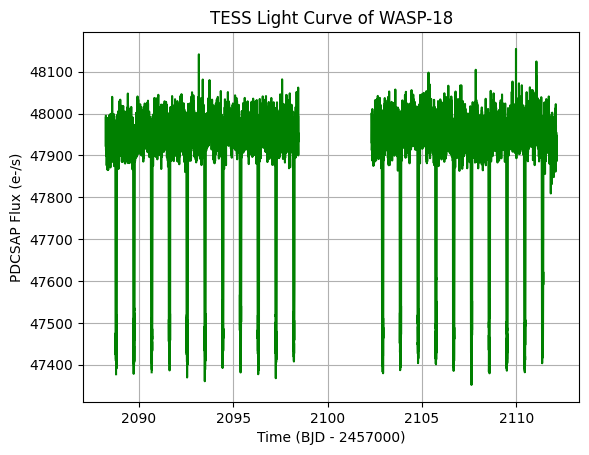

In [12]:
with fits.open(tess_s3_uris[0], fsspec_kwargs={'anon': True}) as tess_hdul:
    tess_hdul.info()
    time = tess_hdul[1].data['TIME']
    flux = tess_hdul[1].data['PDCSAP_FLUX']

# Plot the TESS light curve
plt.plot(time, flux, color='green')
plt.title("TESS Light Curve of WASP-18")
plt.xlabel("Time (BJD - 2457000)")
plt.ylabel("PDCSAP Flux (e-/s)")
plt.grid()
plt.show()

### Opening Timeseries Files with Lightkurve

[`lightkurve`](https://lightkurve.github.io/lightkurve/#) is an open-source Python package that offers user-friendly ways to analyze astronomical time series data. `lightkurve` allow users to read data products from the cloud directly into memory. These data products must be in FITS format.

To read a single data product, simply use the `lightkurve.io.read` method and pass in a cloud URI for either a light curve file or a target pixel file. The function will determine the type of the file and return the corresponding object. From here, you have access to a plethora of attributes and methods for analyzing and visualizing the data.

For a [`LightCurve` object](https://lightkurve.github.io/lightkurve/reference/lightcurve.html), these include, but are not limited to:
- `LightCurve.time`: Time values stored as an `astropy.time.Time` object.
- `LightCurve.flux`: Brightness values stored as an `astropy.units.Quantity` object.
- `LightCurve.plot()`: Plot the light curve.
- `LightCurve.fold()`: Fold the light curve on a given period and epoch.
- `LightCurve.create_transit_mask()`: Returns a boolean array that is `True` during transits and `False` elsewhere.

Below, we will read and plot a single light curve file from the cloud.

Type: <class 'lightkurve.lightcurve.TessLightCurve'>


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

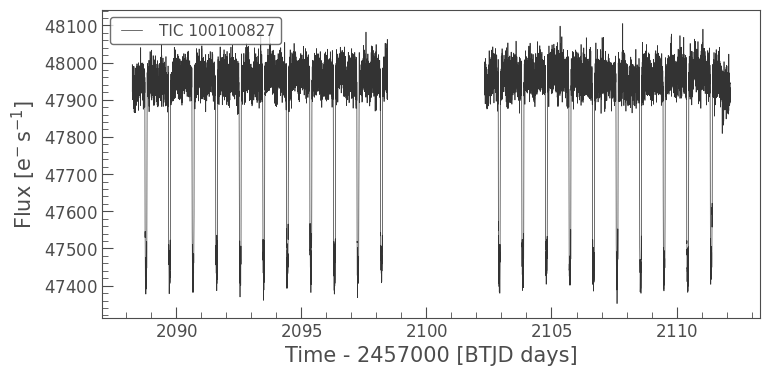

In [13]:
# Read a single light curve file
lc = lk.io.read(tess_s3_uris[0])
print('Type:', type(lc))

# Plot the light curve
lc.plot()

To read a multiple light curve products from the cloud, we can use the `lightkurve.io.read_lc_collection` method. This returns a [`lightkurve.LightCurveCollection` object](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.LightCurveCollection.html?highlight=lightcurvecollection#lightkurve.LightCurveCollection), which holds a collection of `LightCurve` objects and has some additional attributes and methods.

Type: <class 'lightkurve.collections.LightCurveCollection'>


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

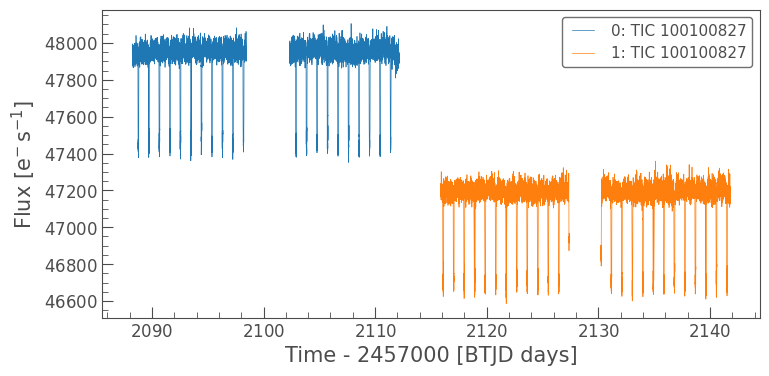

In [14]:
# Read a collection of light curves
collection = lk.io.read_lc_collection(tess_s3_uris[:2])
print('Type:', type(collection))

# Plot the collection
collection.plot()

Notice how each of the light curves is plotted in a different color according to the chart legend. To stitch all of the light curves in the collection into a single `LightCurve` object, we can set the `stitch` argument to be `True`. Each light curve will be normalized prior to stitching.

Type: <class 'lightkurve.lightcurve.TessLightCurve'>


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

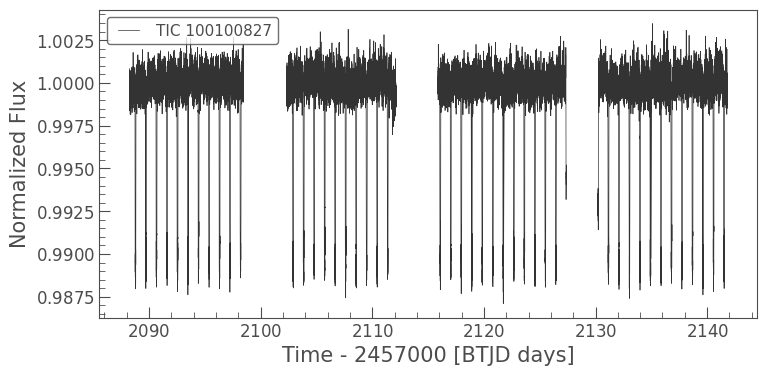

In [15]:
# Read a collection of light curves as a single, stitched light curve
stitched = lk.io.read_lc_collection(tess_s3_uris[:2], stitch=True)
print('Type:', type(stitched))

# Plot the light curve
stitched.plot()

## Exercise: Accessing JWST Spectroscopic Data

It's time to test your knowledge! Using the `Observations` class, search for spectroscopic observations from the [James Webb Space Telescope](https://www.stsci.edu/jwst) around a young supernova. 

- Use the `target_name` parameter to specify the name of a known young supernova (e.g., "SN2026BGD").
- Use the `obs_collection` parameter to restrict your search to the JWST mission.
- Use the `instrument_name` parameter to specify slitted spectrscopy with the [Near Infrared Spectrograph (NIRSpec)](https://science.nasa.gov/mission/webb/nirspec/) instrument on JWST (e.g., "NIRSPEC/SLIT").
- Use the `dataproduct_type` parameter to search for spectroscopic data products (e.g., "spectrum").
- Use the `calib_level` parameter to select fully calibrated data products.

From there, you'll need to filter your products for the minimum recommended products (MRPs) and those with a `productSubGroupDescription` of "ANNN_X1D". This will select the 1D extracted spectra that are typically used for scientific analysis.

Once you have identified the relevant data products, retrieve the S3 URIs for these files, read one of the spectra directly from the cloud, and plot the spectrum using `matplotlib`.

You may choose to separate this exercise into multiple steps (e.g., first write a query to find observations, then filter products, then retrieve S3 URIs, etc.) or you can try to use the streamlined workflow and pass query criteria and product filters directly to `get_cloud_uris()`.

In [16]:
# Query for JWST spectrscopic observations around SN2026BGD

# jwst_s3_uris = Observations.get_cloud_uris(...)

In [17]:
# with fits.open(jwst_s3_uris[0], fsspec_kwargs={'anon': True}) as jwst_hdul:
#     jwst_hdul.info()
#     wavelength = jwst_hdul[1].data['WAVELENGTH']
#     flux = jwst_hdul[1].data['FLUX']

# # Plot the JWST spectrum
# plt.plot(wavelength, flux, color='blue')
# plt.title("JWST Spectrum of SN2026BGD")
# plt.xlabel("Wavelength (microns)")
# plt.ylabel("Flux (erg/s/cm^2/Å)")
# plt.grid()
# plt.show()

## Exercise Solution

In [18]:
# As 3 separate steps
# Query for JWST spectrscopic observations around SN2026BGD
jwst_obs = Observations.query_criteria(target_name="SN2026BGD",
                                       obs_collection="JWST",
                                       instrument_name="NIRSPEC/SLIT",
                                       dataproduct_type="spectrum",
                                       calib_level=3)

# Get products
jwst_prods = Observations.get_product_list(jwst_obs)

# Filter products
filtered_jwst_prods = Observations.filter_products(jwst_prods,
                                                   mrp_only=True,
                                                   productSubGroupDescription="ANNNN_X1D")

# Get cloud URIs for the filtered products
jwst_s3_uris = Observations.get_cloud_uris(filtered_jwst_prods)
jwst_s3_uris

['s3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000014_nirspec_f290lp-g395m-s1600a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000013_nirspec_f290lp-g395m-s400a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000001_nirspec_f290lp-g395m-s200a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000012_nirspec_f290lp-g395m-s200a2_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000001_nirspec_f290lp-g395m-s200a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000012_nirspec_f290lp-g395m-s200a2_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000013_nirspec_f290lp-g395m-s400a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000014_nirspec_f290lp-g395m-s1600a1_x1d.fits']

In [19]:
# Streamlined
jwst_s3_uris = Observations.get_cloud_uris(target_name="SN2026BGD",
                                           obs_collection="JWST",
                                           instrument_name="NIRSPEC/SLIT",
                                           dataproduct_type="spectrum",
                                           calib_level=3,
                                           mrp_only=True,
                                           filter_products={"productSubGroupDescription": "ANNNN_X1D"})
jwst_s3_uris

['s3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000014_nirspec_f290lp-g395m-s1600a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000013_nirspec_f290lp-g395m-s400a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000001_nirspec_f290lp-g395m-s200a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o008/jw09255-o008_t007-s000000012_nirspec_f290lp-g395m-s200a2_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000001_nirspec_f290lp-g395m-s200a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000012_nirspec_f290lp-g395m-s200a2_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000013_nirspec_f290lp-g395m-s400a1_x1d.fits',
 's3://stpubdata/jwst/public/jw09255/L3/t/o010/jw09255-o010_t007-s000000014_nirspec_f290lp-g395m-s1600a1_x1d.fits']

## Additional Resources

- [`astroquery.mast` Documentation for Observation Queries](https://astroquery.readthedocs.io/en/latest/mast/mast_obsquery.html)
- [Registry of STScI Open Data on AWS](https://registry.opendata.aws/collab/stsci/)

## Citations

If you use `astroquery` for published research, please cite the
authors. Follow these links for more information about citing `astroquery`:

* [Citing Astroquery](https://github.com/astropy/astroquery/blob/main/astroquery/CITATION)

## About this Notebook

**Author:** Sam Bianco <br>
**Keywords:** Astroquery, Observations, Cloud <br>

***
[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/style-guides/master/guides/images/stsci-logo.png" alt="Space Telescope Logo" width="200px"/> 